# Solutions · 10 · Fitting implicit models: how rough is this pipe?

Worked solutions to the exercises of [notebook 10](../notebooks/10_implicit_models_optimisation.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import datasets, optimize, roots
rho, mu, L, D = 998.0, 1.0e-3, 20.0, 0.05
meas = np.loadtxt(datasets.path("pipe_pressure_drop.csv"), delimiter=",", skiprows=1)
Q, dp = meas[:, 0], meas[:, 1]
eps_true, k_true = 0.15e-3, 1.03
def colebrook_f(Re, eps):
    return roots.brent(lambda f: 1/np.sqrt(f) + 2*np.log10(eps/D/3.7 + 2.51/(Re*np.sqrt(f))), 1e-4, 0.2).root
def dp_model(Q, eps, k=1.0, friction=colebrook_f):
    v = 4*k*np.atleast_1d(Q)/(np.pi*D**2)
    Re = rho*v*D/mu
    return np.array([friction(R, eps) for R in Re]) * L/D * rho*v**2/2
def fit(objective):
    r = optimize.nelder_mead(lambda p: objective(p[0], p[1]), [-4.0, 1.0], step=0.05, tol=1e-12)
    return 10**r.x[0], r.x[1]
rel_rss = lambda le, k: np.sum(np.log(dp_model(Q, 10**le, k) / dp)**2)
eps_rel, k_rel = fit(rel_rss)

## Exercise 1

Repeat the two-parameter fit with absolute residuals $\sum(\Delta P_{model} - \Delta P)^2$. How much
   do the estimates change, and why?

In [2]:
abs_rss = lambda le, k: np.sum((dp_model(Q, 10**le, k) - dp)**2)
eps_abs, k_abs = fit(abs_rss)
print(f"relative residuals: eps = {eps_rel*1000:.3f} mm, k = {k_rel:.4f}")
print(f"absolute residuals: eps = {eps_abs*1000:.3f} mm, k = {k_abs:.4f}   (truth {eps_true*1000} mm, {k_true})")
print(f"share of the absolute RSS scale: largest ΔP² / sum ΔP² = {dp.max()**2 / np.sum(dp**2):.0%}")

relative residuals: eps = 0.168 mm, k = 1.0166
absolute residuals: eps = 0.283 mm, k = 0.9490   (truth 0.15 mm, 1.03)
share of the absolute RSS scale: largest ΔP² / sum ΔP² = 64%


With absolute residuals the two highest flows carry most of the weight (the largest pressure drop alone
accounts for over half of $\sum \Delta P^2$), so the estimates are driven by very few points and change
noticeably. With a *relative* measurement error (2 % here), relative - logarithmic - residuals give every
measurement its fair weight.

## Exercise 2

Add three laminar points ($Re$ < 2000, use $f = 64/Re$) to the data and refit. How does the shape
   of the valley change?

turbulent data only : log10 eps = -3.774 ± 0.117 (eps 0.168 mm), k = 1.0166 ± 0.0321, correlation -0.987
with laminar points : log10 eps = -3.768 ± 0.048 (eps 0.171 mm), k = 1.0151 ± 0.0128, correlation -0.941
truth: eps = 0.15 mm, k = 1.03


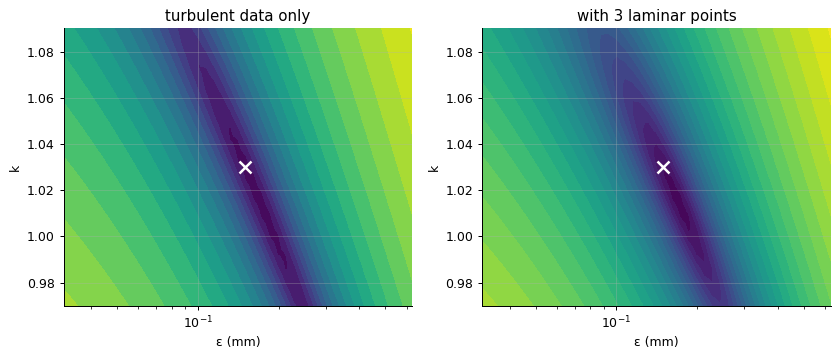

In [3]:
nu = mu / rho
Q_lam = np.array([2e-5, 4e-5, 6e-5])                                  # Re < 2000
v_lam = 4*k_true*Q_lam/(np.pi*D**2)
dp_lam = 64/(v_lam*D/nu) * L/D * rho*v_lam**2/2 * (1 + 0.02*np.random.default_rng(9).standard_normal(3))
Q_all, dp_all = np.r_[Q_lam, Q], np.r_[dp_lam, dp]
def friction_any(Re, eps):
    return 64/Re if Re < 2000 else colebrook_f(Re, eps)
rss_all = lambda le, k: np.sum(np.log(dp_model(Q_all, 10**le, k, friction_any) / dp_all)**2)
from engmath import fitting
def log_dp(Qs, log_eps, k):          # log of the model pressure drop: the residual we minimise
    return np.log(dp_model(Qs, 10**log_eps, k, friction_any))
for label, Qs, dps in (("turbulent data only", Q, dp), ("with laminar points", Q_all, dp_all)):
    f = fitting.levenberg_marquardt(log_dp, Qs, np.log(dps), [-3.8, 1.0])
    print(f"{label:<20}: log10 eps = {f.coef[0]:.3f} ± {f.se[0]:.3f} (eps {10**f.coef[0]*1000:.3f} mm), "
          f"k = {f.coef[1]:.4f} ± {f.se[1]:.4f}, correlation {f.correlation[0, 1]:+.3f}")
print(f"truth: eps = {eps_true*1000} mm, k = {k_true}")
le = np.linspace(-4.5, -3.2, 45); kk = np.linspace(0.97, 1.09, 45)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, obj, title in ((axs[0], rel_rss, "turbulent data only"), (axs[1], rss_all, "with 3 laminar points")):
    Z = np.array([[obj(a, b) for a in le] for b in kk])
    ax.contourf(10**le*1000, kk, np.log10(Z), levels=25, cmap="viridis")
    ax.plot(eps_true*1000, k_true, "wx", ms=10, mew=2)
    ax.set(xscale="log", xlabel="ε (mm)", ylabel="k", title=title)
plt.show()

In laminar flow $f = 64/Re$ does not depend on roughness at all, so laminar points pin down the meter
factor $k$ on their own. The valley becomes shorter, and the **standard errors** of both parameters fall
by a factor of about 2.5, with a weaker correlation between them. Judge an experimental design by these
uncertainties, not by whether one noisy data set happens to land closer to the truth: in both fits the
true values lie within about 1.2 standard errors. A few well-chosen extra measurements do more than
many more of the same kind: **design experiments to break parameter correlations.**

## Exercise 3

Replace Colebrook with the explicit Haaland approximation inside the model. How large is the
   resulting bias in $\varepsilon$, and is it smaller than the statistical uncertainty?

In [4]:
def haaland_f(Re, eps):
    return (-1.8*np.log10((eps/D/3.7)**1.11 + 6.9/Re))**-2
hl_rss = lambda le, k: np.sum(np.log(dp_model(Q, 10**le, k, haaland_f) / dp)**2)
eps_h, k_h = fit(hl_rss)
print(f"Colebrook model: eps = {eps_rel*1000:.3f} mm, k = {k_rel:.4f}")
print(f"Haaland model:   eps = {eps_h*1000:.3f} mm, k = {k_h:.4f}")
from engmath import fitting
f = fitting.levenberg_marquardt(lambda Qs, le, k: np.log(dp_model(Qs, 10**le, k)), Q, np.log(dp), [-3.8, 1.0])
se_eps = 10**f.coef[0] * np.log(10) * f.se[0]
print(f"model bias in eps: {abs(eps_h - eps_rel)*1000:.3f} mm;  statistical standard error of eps: {se_eps*1000:.3f} mm")

Colebrook model: eps = 0.168 mm, k = 1.0166
Haaland model:   eps = 0.156 mm, k = 1.0277
model bias in eps: 0.012 mm;  statistical standard error of eps: 0.045 mm


The bias caused by the approximate friction formula is about a quarter of the statistical standard error
of the roughness, which comes from the measurement noise and the parameter correlation. Here the cheaper
explicit formula would be acceptable - but that is a conclusion to *check*, not to assume.

## Exercise 4

**Implement it yourself:** a grid search over $\log_{10}\varepsilon \in [-6, -2.5]$ that reaches the same final precision needs how many evaluations? Implement it and compare with golden-section search.

In [5]:
span, tol = 3.5, 1e-6
gs = optimize.golden_section(lambda le: rel_rss(le, 1.0), -6, -2.5, tol=tol)
print(f"golden-section search: {gs.iterations + 2} evaluations")
print(f"grid search to the same precision: {int(span/tol) + 1:,} evaluations")
for n in (36, 351, 3501):
    grid = np.linspace(-6, -2.5, n)
    best = grid[np.argmin([rel_rss(g, 1.0) for g in grid])] if n <= 351 else None
    if best is not None:
        print(f"grid of {n:>4} points: eps = {10**best*1000:.4f} mm (spacing {span/(n-1):.3f} in log10)")
print(f"golden section:       eps = {10**gs.x[0]*1000:.4f} mm")

golden-section search: 30 evaluations
grid search to the same precision: 3,500,001 evaluations
grid of   36 points: eps = 0.1995 mm (spacing 0.100 in log10)
grid of  351 points: eps = 0.1950 mm (spacing 0.010 in log10)
golden section:       eps = 0.1929 mm


Each golden-section step shrinks the bracket by 0.618, so reaching a precision of $10^{-6}$ in
$\log_{10}\varepsilon$ from a bracket of width 3.5 takes about 30 evaluations; a uniform grid needs
3.5 million. For expensive models - here every evaluation solves eight Colebrook equations - the choice of
algorithm matters enormously. Grids remain useful for a first look at the landscape.